[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab1-NetworkSci-PSN/notebooks/01-networkx_tutorial.ipynb)

Version 2025-12-21, A. Lundervold

# NetworkX Tutorial: Graph Analysis in Python

<img src="../assets/networkx_banner.svg" width="250">

Welcome to this hands-on introduction to **NetworkX** – the Python library for creating, manipulating, and analyzing complex networks and graphs.

---

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

| Skill | Description |
|-------|-------------|
| **Create graphs** | Build undirected, directed, and weighted graphs from scratch |
| **Manipulate nodes and edges** | Add, remove, and modify elements in a graph |
| **Use attributes** | Attach metadata to graphs, nodes, and edges |
| **Analyze structures** | Calculate centrality, clustering, and shortest paths |
| **Visualize networks** | Draw and export graphs to various formats |
| **Use graph generators** | Create standard graphs used in research |

---

## 🏥 Why NetworkX in Medicine and Biology?

In biomedical research and clinical practice, we constantly encounter **relational data** that can naturally be represented as networks:

### Biomedical Applications

| Application | Nodes | Edges | Medical Insight |
|-------------|-------|-------|-----------------|
| **Protein interaction networks** | Proteins | Physical bindings | Identify key proteins in disease processes |
| **Gene regulatory networks** | Genes | Regulatory relationships | Understand gene expression patterns in cancer |
| **Disease comorbidity networks** | Diagnoses | Shared patients | Discover unknown disease relationships |
| **Patient similarity networks** | Patients | Clinical similarity | Subtype identification and precision medicine |
| **Brain connectivity networks** | Brain regions | Structural/functional connections | Map neurological conditions |
| **Epidemiological networks** | Individuals | Infection contacts | Model disease spread |

> 💡 **NetworkX** provides us with the tools to **construct**, **analyze**, and **visualize** all these network types in Python.

---

## 📚 About This Guide

This guide is adapted from the official [NetworkX tutorial](https://networkx.org/documentation/latest/tutorial.html) ([LICENSE](https://github.com/networkx/networkx/blob/main/LICENSE.txt)) with:

- 🇬🇧 English language and explanations
- 🏥 Medical and biological examples
- 📝 Extended documentation and context
- 🎓 Didactic additions for students

**Prerequisites:** Basic Python knowledge. See the [Python tutorial](https://docs.python.org/3/tutorial/index.html) if needed.

---

## ⚙️ Setup and Environment Check

In [24]:
# ============================================================================
# ENVIRONMENT CHECK: Are we in Google Colab or a local environment?
# ============================================================================
# We perform this check in all course notebooks because some operations
# (such as file paths and package installation) are handled differently.

try:
    import google.colab
    is_colab = True
    print("🌐 Running in Google Colab")
    print("   → Some packages will be installed automatically as needed")
except ImportError:
    is_colab = False
    print("💻 Running locally")
    print("   → Using the conda environment bmed365-2026")

💻 Running locally
   → Using the conda environment bmed365-2026


In [26]:
# ============================================================================
# IMPORT NETWORKX
# ============================================================================
# NetworkX is the main library for network analysis in Python.
# The convention is to import it as 'nx' for shorter code.

import networkx as nx

print(f"✓ NetworkX version: {nx.__version__}")
print("")
print("NetworkX provides us with tools to:")
print("  • Create and manipulate graphs")
print("  • Calculate network metrics")
print("  • Visualize networks")
print("  • Read/write graph data in various formats")

✓ NetworkX version: 3.4.2

NetworkX provides us with tools to:
  • Create and manipulate graphs
  • Calculate network metrics
  • Visualize networks
  • Read/write graph data in various formats


---

# 1️⃣ Creating Graphs

## What is a Graph in Programming Terms?

In NetworkX, a **graph** (`Graph`) is a data structure that contains:
- **Nodes** (vertices) – the objects we study
- **Edges** – the connections between them

### Graph Types in NetworkX

| Class | Type | Description | Medical Example |
|-------|------|-------------|-----------------|
| `Graph` | Undirected | Edges go both ways | Patient similarity network |
| `DiGraph` | Directed | Edges have direction | Signaling pathways in cells |
| `MultiGraph` | Undirected, multiple edges | Multiple edges between same nodes | Different relationship types |
| `MultiDiGraph` | Directed, multiple edges | Combination of above | Complex regulatory networks |

Let's start with the simplest type – an undirected graph.

In [27]:
# ============================================================================
# CREATE AN EMPTY GRAPH
# ============================================================================
# We start with a completely empty graph – no nodes, no edges.
# Think of it as a blank canvas where we will draw a network.

G = nx.Graph()

print(f"Created an empty graph of type: {type(G).__name__}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Created an empty graph of type: Graph
Number of nodes: 0
Number of edges: 0


---

# 2️⃣ Working with Nodes

## What Can Be a Node?

In NetworkX, nodes can be **any [hashable Python objects](https://docs.python.org/3/glossary.html#term-hashable)**:
- Numbers (integers, floats)
- Text strings
- Tuples
- Even other graphs!

> 🏥 **Medical context:** Nodes can represent patients (ID numbers), diagnoses (ICD codes), proteins (UniProt IDs), or brain regions (anatomical names).

### Adding Nodes

In [28]:
# ============================================================================
# ADDING NODES – ONE AT A TIME AND IN GROUPS
# ============================================================================

# Method 1: Add one node at a time
# Here we use patient IDs as an example
G.add_node("Patient_001")

print("After adding one patient:")
print(f"  Nodes: {list(G.nodes)}")

After adding one patient:
  Nodes: ['Patient_001']


In [29]:
# ============================================================================
# ADDING MULTIPLE NODES AT ONCE
# ============================================================================
# When we have many nodes, it's more efficient to add from a list.

# Method 2: Add from a list (iterable)
patients = ["Patient_002", "Patient_003", "Patient_004"]
G.add_nodes_from(patients)

print("After adding multiple patients:")
print(f"  Nodes: {list(G.nodes)}")
print(f"  Count: {G.number_of_nodes()}")

After adding multiple patients:
  Nodes: ['Patient_001', 'Patient_002', 'Patient_003', 'Patient_004']
  Count: 4


In [32]:
# ============================================================================
# ADDING NODES WITH ATTRIBUTES
# ============================================================================
# Nodes can have associated data – very useful in medical applications!
# We use tuples in the form (node_id, {attribute_dict})

# Example: Patients with age and diagnosis
patients_with_data = [
    ("Patient_005", {"age": 45, "diagnosis": "Hypertension"}),
    ("Patient_006", {"age": 62, "diagnosis": "Type 2 diabetes"}),
    ("Patient_007", {"age": 38, "diagnosis": "Asthma"})
]
G.add_nodes_from(patients_with_data)

print("Patients with attributes:")
for node in ["Patient_005", "Patient_006", "Patient_007"]:
    print(f"  {node}: {G.nodes[node]}")

Patients with attributes:
  Patient_005: {'age': 45, 'diagnosis': 'Hypertension'}
  Patient_006: {'age': 62, 'diagnosis': 'Type 2 diabetes'}
  Patient_007: {'age': 38, 'diagnosis': 'Asthma'}


In [33]:
# ============================================================================
# TRANSFER NODES FROM ANOTHER GRAPH
# ============================================================================
# We can copy nodes from an existing graph.
# Here we first create a path graph with 5 nodes (0, 1, 2, 3, 4).

# A path graph is a simple chain of nodes
path_graph = nx.path_graph(5)
print(f"Path graph nodes: {list(path_graph.nodes)}")

# Add these nodes to our main graph
G.add_nodes_from(path_graph)
print(f"\nMain graph after import:")
print(f"  All nodes: {list(G.nodes)}")
print(f"  Total count: {G.number_of_nodes()}")

Path graph nodes: [0, 1, 2, 3, 4]

Main graph after import:
  All nodes: ['Patient_001', 'Patient_002', 'Patient_003', 'Patient_004', 'Patient_005', 'Patient_006', 'Patient_007', 0, 1, 2, 3, 4]
  Total count: 12


### 💡 The Flexibility of NetworkX

An interesting property of NetworkX is that a graph itself can be a node in another graph! This opens up **hierarchical structures** – for example, a hospital (represented as a network of departments) can be a node in a regional health network.

In [34]:
# ============================================================================
# A GRAPH AS A NODE
# ============================================================================
# Demonstration of hierarchical structure

# Create a small "hospital" network
hospital = nx.Graph(name="Haukeland")
hospital.add_nodes_from(["Emergency", "Surgery", "Medicine", "Radiology"])
hospital.add_edges_from([("Emergency", "Surgery"), ("Emergency", "Radiology")])

# Create a regional network and add the hospital as a node
region = nx.Graph(name="Western Norway Regional Health Authority")
region.add_node(hospital)  # The entire graph becomes a node!
region.add_node("Stavanger University Hospital")
region.add_node("Førde Central Hospital")

print(f"Regional network '{region.graph.get('name', 'unknown')}'")
print(f"  Number of nodes: {region.number_of_nodes()}")
print(f"  Type of first node: {type(list(region.nodes)[0])}")

Regional network 'Western Norway Regional Health Authority'
  Number of nodes: 3
  Type of first node: <class 'networkx.classes.graph.Graph'>


---

# 3️⃣ Working with Edges

## What Does an Edge Represent?

An **edge** is a connection between two nodes. In medical networks, edges can represent:

| Network Type | Edge Meaning |
|--------------|--------------|
| Patient similarity | Degree of clinical similarity between patients |
| Protein interaction | Physical binding between proteins |
| Comorbidity | Two diagnoses that often occur together |
| Epidemiology | Infection contact between individuals |
| Gene regulation | One gene regulates another |

### Adding Edges


In [35]:
# ============================================================================
# ADDING EDGES – ONE AT A TIME
# ============================================================================
# Let's start with a new, clean graph for this example.

# Create graph for patient similarity network
PSN = nx.Graph(name="Patient Similarity Network")

# Add an edge between two patients
# Note: Nodes are created automatically if they don't exist!
PSN.add_edge("Patient_A", "Patient_B")

print("After adding one edge:")
print(f"  Nodes: {list(PSN.nodes)}")
print(f"  Edges: {list(PSN.edges)}")


After adding one edge:
  Nodes: ['Patient_A', 'Patient_B']
  Edges: [('Patient_A', 'Patient_B')]


In [36]:
# ============================================================================
# ADDING MULTIPLE EDGES AT ONCE
# ============================================================================
# Efficient way to build networks – add many edges from a list.

# List of patient similarities (edges)
similarities = [
    ("Patient_A", "Patient_C"),
    ("Patient_B", "Patient_C"),
    ("Patient_C", "Patient_D"),
    ("Patient_D", "Patient_E"),
    ("Patient_A", "Patient_E")
]
PSN.add_edges_from(similarities)

print("Patient Similarity Network:")
print(f"  Number of patients (nodes): {PSN.number_of_nodes()}")
print(f"  Number of similarity relationships (edges): {PSN.number_of_edges()}")
print(f"  Edges: {list(PSN.edges)}")


Patient Similarity Network:
  Number of patients (nodes): 5
  Number of similarity relationships (edges): 6
  Edges: [('Patient_A', 'Patient_B'), ('Patient_A', 'Patient_C'), ('Patient_A', 'Patient_E'), ('Patient_B', 'Patient_C'), ('Patient_C', 'Patient_D'), ('Patient_D', 'Patient_E')]


In [37]:
# ============================================================================
# ADDING WEIGHTED EDGES
# ============================================================================
# In medical networks, edges are often weighted – e.g., degree of similarity.
# We can add weights as attributes.

# Create new network with weighted edges
PSN_weighted = nx.Graph(name="Weighted Patient Similarity Network")

# Add edges with similarity scores (weight between 0 and 1)
weighted_similarities = [
    ("P1", "P2", 0.85),   # High similarity
    ("P1", "P3", 0.42),   # Moderate similarity
    ("P2", "P3", 0.91),   # Very high similarity
    ("P2", "P4", 0.67),   # Good similarity
    ("P3", "P4", 0.35)    # Low similarity
]
PSN_weighted.add_weighted_edges_from(weighted_similarities)

print("Weighted Patient Similarity Network:")
for u, v, data in PSN_weighted.edges(data=True):
    print(f"  {u} ↔ {v}: similarity = {data['weight']:.2f}")


Weighted Patient Similarity Network:
  P1 ↔ P2: similarity = 0.85
  P1 ↔ P3: similarity = 0.42
  P2 ↔ P3: similarity = 0.91
  P2 ↔ P4: similarity = 0.67
  P3 ↔ P4: similarity = 0.35


---

# 4️⃣ Examining Graph Elements

## Views in NetworkX

NetworkX offers four basic **views** to examine a graph's structure:

| View | Description | Example |
|------|-------------|---------|
| `G.nodes` | All nodes in the graph | List of patients |
| `G.edges` | All edges in the graph | List of similarity relationships |
| `G.adj` | Neighbors for each node | Who is similar to whom? |
| `G.degree` | Number of edges per node | How many are similar to this patient? |

These views are **"live"** – they update automatically when the graph changes.


In [38]:
# ============================================================================
# EXAMINING THE GRAPH
# ============================================================================
# Let's use the PSN (patient similarity network) we created earlier.

print("=" * 50)
print("EXAMINATION OF PATIENT SIMILARITY NETWORK")
print("=" * 50)

# Nodes (patients)
print(f"\n📋 All patients (nodes):")
print(f"   {list(PSN.nodes)}")

# Edges (similarity relationships)
print(f"\n🔗 All similarity relationships (edges):")
for edge in PSN.edges:
    print(f"   {edge[0]} ↔ {edge[1]}")

# Neighbors of a specific patient
print(f"\n👥 Patients similar to Patient_A:")
print(f"   {list(PSN.adj['Patient_A'])}")

# Degree (number of similarity relationships)
print(f"\n📊 Number of similarity relationships per patient (degree):")
for node, degree in PSN.degree():
    print(f"   {node}: {degree} similarity relationships")


EXAMINATION OF PATIENT SIMILARITY NETWORK

📋 All patients (nodes):
   ['Patient_A', 'Patient_B', 'Patient_C', 'Patient_D', 'Patient_E']

🔗 All similarity relationships (edges):
   Patient_A ↔ Patient_B
   Patient_A ↔ Patient_C
   Patient_A ↔ Patient_E
   Patient_B ↔ Patient_C
   Patient_C ↔ Patient_D
   Patient_D ↔ Patient_E

👥 Patients similar to Patient_A:
   ['Patient_B', 'Patient_C', 'Patient_E']

📊 Number of similarity relationships per patient (degree):
   Patient_A: 3 similarity relationships
   Patient_B: 2 similarity relationships
   Patient_C: 3 similarity relationships
   Patient_D: 2 similarity relationships
   Patient_E: 2 similarity relationships


---

# 5️⃣ Removing Elements

## Cleaning and Modifying Networks

In data analysis, we often need to filter out nodes or edges – for example, patients who don't meet inclusion criteria, or weak connections below a threshold value.

| Method | Function |
|--------|----------|
| `G.remove_node(n)` | Remove one node (and all its edges) |
| `G.remove_nodes_from(list)` | Remove multiple nodes |
| `G.remove_edge(u, v)` | Remove one edge |
| `G.remove_edges_from(list)` | Remove multiple edges |
| `G.clear()` | Clear the entire graph |


In [39]:
# ============================================================================
# REMOVING NODES AND EDGES
# ============================================================================

# Make a copy of PSN to demonstrate
test_graph = PSN.copy()
print(f"Before removal:")
print(f"  Nodes: {list(test_graph.nodes)}")
print(f"  Edges: {list(test_graph.edges)}")

# Remove a patient (and all their similarity relationships)
test_graph.remove_node("Patient_E")
print(f"\nAfter removing Patient_E:")
print(f"  Nodes: {list(test_graph.nodes)}")
print(f"  Edges: {list(test_graph.edges)}")

# Remove a specific similarity relationship
test_graph.remove_edge("Patient_A", "Patient_B")
print(f"\nAfter removing edge A-B:")
print(f"  Edges: {list(test_graph.edges)}")


Before removal:
  Nodes: ['Patient_A', 'Patient_B', 'Patient_C', 'Patient_D', 'Patient_E']
  Edges: [('Patient_A', 'Patient_B'), ('Patient_A', 'Patient_C'), ('Patient_A', 'Patient_E'), ('Patient_B', 'Patient_C'), ('Patient_C', 'Patient_D'), ('Patient_D', 'Patient_E')]

After removing Patient_E:
  Nodes: ['Patient_A', 'Patient_B', 'Patient_C', 'Patient_D']
  Edges: [('Patient_A', 'Patient_B'), ('Patient_A', 'Patient_C'), ('Patient_B', 'Patient_C'), ('Patient_C', 'Patient_D')]

After removing edge A-B:
  Edges: [('Patient_A', 'Patient_C'), ('Patient_B', 'Patient_C'), ('Patient_C', 'Patient_D')]


---

# 6️⃣ Attributes on Graphs, Nodes, and Edges

## Storing Metadata in the Graph

Attributes are **key-value pairs** that can be attached to:
- **The graph itself** – metadata about the entire network
- **Nodes** – properties of each object
- **Edges** – properties of each relationship

> 🏥 **Medical utility:** Attributes allow us to store rich information – patient demographics, biomarker values, diagnosis codes, laboratory values, etc.


In [42]:
# ============================================================================
# GRAPH, NODE, AND EDGE ATTRIBUTES
# ============================================================================

# Create graph with metadata
study = nx.Graph(
    name="IBS Cohort Study",
    date="2024-01-15",
    n_patients=78,
    institution="Haukeland University Hospital"
)

print("📋 Graph attributes:")
for key, value in study.graph.items():
    print(f"   {key}: {value}")

# Add patients with clinical data
study.add_node("IBS_001", age=34, sex="F", IBS_SSS=285, anxiety_score=12)
study.add_node("IBS_002", age=45, sex="M", IBS_SSS=312, anxiety_score=8)
study.add_node("IBS_003", age=28, sex="F", IBS_SSS=198, anxiety_score=15)

print("\n👤 Node attributes (patient data):")
for node, data in study.nodes(data=True):
    print(f"   {node}: {data}")

# Add edges with similarity scores
study.add_edge("IBS_001", "IBS_002", similarity=0.78, method="euclidean", p_value=0.003)
study.add_edge("IBS_001", "IBS_003", similarity=0.65, method="euclidean", p_value=0.01)
study.add_edge("IBS_002", "IBS_003", similarity=0.52, method="euclidean", p_value=0.042)

print("\n🔗 Edge attributes (similarity data):")
for u, v, data in study.edges(data=True):
    print(f"   {u} ↔ {v}: {data}")


📋 Graph attributes:
   name: IBS Cohort Study
   date: 2024-01-15
   n_patients: 78
   institution: Haukeland University Hospital

👤 Node attributes (patient data):
   IBS_001: {'age': 34, 'sex': 'F', 'IBS_SSS': 285, 'anxiety_score': 12}
   IBS_002: {'age': 45, 'sex': 'M', 'IBS_SSS': 312, 'anxiety_score': 8}
   IBS_003: {'age': 28, 'sex': 'F', 'IBS_SSS': 198, 'anxiety_score': 15}

🔗 Edge attributes (similarity data):
   IBS_001 ↔ IBS_002: {'similarity': 0.78, 'method': 'euclidean', 'p_value': 0.003}
   IBS_001 ↔ IBS_003: {'similarity': 0.65, 'method': 'euclidean', 'p_value': 0.01}
   IBS_002 ↔ IBS_003: {'similarity': 0.52, 'method': 'euclidean', 'p_value': 0.042}


---

# 7️⃣ Directed Graphs (DiGraph)

## When Direction Matters

In many biological contexts, relationships have a **direction**:

| Example | Meaning of Direction |
|---------|---------------------|
| Gene → Protein | Transcription direction |
| Transcription factor → Gene | Regulatory control |
| Neuron A → Neuron B | Signal transmission |
| Enzyme → Substrate | Catalytic reaction |

For such networks, we use **[DiGraph](https://networkx.org/documentation/stable/reference/classes/digraph.html)** (directed graph).


In [45]:
# ============================================================================
# DIRECTED GRAPH: GENE REGULATORY NETWORK
# ============================================================================

# Create directed graph
regulation = nx.DiGraph(name="Gene Regulatory Network")

# Add regulatory edges (TF → target gene)
regulation.add_edge("TP53", "p21", effect="activation", strength=0.9)
regulation.add_edge("TP53", "BAX", effect="activation", strength=0.7)
regulation.add_edge("MYC", "p21", effect="inhibition", strength=0.6)
regulation.add_edge("MYC", "CDK4", effect="activation", strength=0.8)
regulation.add_edge("RB1", "E2F1", effect="inhibition", strength=0.85)
regulation.add_edge("E2F1", "MYC", effect="activation", strength=0.5)

print("Gene Regulatory Network:")
print(f"  Genes/proteins: {list(regulation.nodes)}")
print(f"  Regulations: {regulation.number_of_edges()}")

# Special methods for directed graphs
node = "TP53"
print(f"\nAnalysis of {node}:")
print(f"  → Regulates (successors): {list(regulation.successors(node))}")
print(f"  ← Regulated by (predecessors): {list(regulation.predecessors(node))}")
print(f"  Out-degree: {regulation.out_degree(node)}")
print(f"  In-degree: {regulation.in_degree(node)}")


Gene Regulatory Network:
  Genes/proteins: ['TP53', 'p21', 'BAX', 'MYC', 'CDK4', 'RB1', 'E2F1']
  Regulations: 6

Analysis of TP53:
  → Regulates (successors): ['p21', 'BAX']
  ← Regulated by (predecessors): []
  Out-degree: 2
  In-degree: 0


---

# 8️⃣ Graph Generators

## Pre-built Network Structures

NetworkX has many built-in **graph generators** that are useful for:
- Testing and development
- Simulation of network models
- Comparison with empirical networks

### Classical and Stochastic Graph Models

| Model | Property | Biological Example |
|-------|----------|-------------------|
| **Complete graph** | All nodes connected | Idealized interaction |
| **Erdős-Rényi** | [Random connection](https://en.wikipedia.org/wiki/Erd%C5%91s%E2%80%93R%C3%A9nyi_model) | Null model for comparison |
| **Watts-Strogatz** | [Small-world](https://en.wikipedia.org/wiki/Small-world_network) | Neural networks in the brain |
| **Barabási-Albert** | [Scale-free](https://en.wikipedia.org/wiki/Scale-free_network) (hubs) | Protein interactions, metabolism |


In [48]:
# ============================================================================
# STOCHASTIC GRAPH MODELS
# ============================================================================
# These models are important for simulating and understanding network properties.

import numpy as np
np.random.seed(42)  # For reproducibility

# 1. Erdős-Rényi random graph
# Each pair of nodes has probability p of having an edge
ER = nx.erdos_renyi_graph(n=100, p=0.05, seed=42)
print("Erdős-Rényi random graph (n=100, p=0.05):")
print(f"  Edges: {ER.number_of_edges()}")
print(f"  Average degree: {sum(dict(ER.degree()).values()) / ER.number_of_nodes():.2f}")

# 2. Watts-Strogatz "small-world" graph
# Combines high clustering with short average path length
WS = nx.watts_strogatz_graph(n=50, k=4, p=0.1, seed=42)
print(f"\nWatts-Strogatz small-world (n=50, k=4, p=0.1):")
print(f"  Clustering coefficient: {nx.average_clustering(WS):.3f}")

# 3. Barabási-Albert preferential attachment (scale-free)
# New nodes connect to existing nodes proportionally to their degree
BA = nx.barabasi_albert_graph(n=100, m=2, seed=42)
print(f"\nBarabási-Albert scale-free (n=100, m=2):")
degrees = sorted([d for n, d in BA.degree()], reverse=True)
print(f"  Highest degrees (hubs): {degrees[:5]}")
print(f"  → Typical for 'hub' structure in biological networks")


Erdős-Rényi random graph (n=100, p=0.05):
  Edges: 224
  Average degree: 4.48

Watts-Strogatz small-world (n=50, k=4, p=0.1):
  Clustering coefficient: 0.343

Barabási-Albert scale-free (n=100, m=2):
  Highest degrees (hubs): [36, 25, 20, 13, 10]
  → Typical for 'hub' structure in biological networks


---

# 9️⃣ Graph Analysis

## Calculating Network Metrics

NetworkX offers a wide range of algorithms for analyzing network structure. Here we look at some of the most important ones.

### Centrality Analysis

Centrality measures help us identify the **most important nodes** in a network:

| Centrality | Question | Medical Application |
|------------|----------|---------------------|
| **[Degree](https://en.wikipedia.org/wiki/Degree_centrality)** | Who has the most connections? | Patient with many similarity relationships |
| **[Betweenness](https://en.wikipedia.org/wiki/Betweenness_centrality)** | Who lies on the most shortest paths? | Key protein in signaling pathways |
| **[Closeness](https://en.wikipedia.org/wiki/Closeness_centrality)** | Who can reach everyone fastest? | Central symptom in symptom network |
| **[Eigenvector](https://en.wikipedia.org/wiki/Eigenvector_centrality)** | Who is connected to important nodes? | Influential disease in comorbidity |


In [50]:
# ============================================================================
# CENTRALITY ANALYSIS
# ============================================================================

print("=" * 50)
print("CENTRALITY ANALYSIS OF BARABÁSI-ALBERT NETWORK")
print("=" * 50)

# Degree centrality
degree_centrality = nx.degree_centrality(BA)
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\n1️⃣ Top 5 nodes by degree centrality:")
for node, value in top_degree:
    print(f"   Node {node}: {value:.4f}")

# Betweenness centrality
betweenness = nx.betweenness_centrality(BA)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\n2️⃣ Top 5 nodes by betweenness centrality:")
for node, value in top_betweenness:
    print(f"   Node {node}: {value:.4f}")

# Eigenvector centrality
eigenvector = nx.eigenvector_centrality(BA, max_iter=1000)
top_eigenvector = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\n3️⃣ Top 5 nodes by eigenvector centrality:")
for node, value in top_eigenvector:
    print(f"   Node {node}: {value:.4f}")

print("\n💡 Note: The same nodes often have high centrality across multiple measures!")
print("   This is typical for 'hub' nodes in scale-free networks.")


CENTRALITY ANALYSIS OF BARABÁSI-ALBERT NETWORK

1️⃣ Top 5 nodes by degree centrality:
   Node 0: 0.3636
   Node 4: 0.2525
   Node 1: 0.2020
   Node 5: 0.1313
   Node 6: 0.1010

2️⃣ Top 5 nodes by betweenness centrality:
   Node 0: 0.4088
   Node 4: 0.2537
   Node 1: 0.2182
   Node 5: 0.1168
   Node 6: 0.0876

3️⃣ Top 5 nodes by eigenvector centrality:
   Node 0: 0.4987
   Node 4: 0.3306
   Node 1: 0.3211
   Node 5: 0.2047
   Node 2: 0.1431

💡 Note: The same nodes often have high centrality across multiple measures!
   This is typical for 'hub' nodes in scale-free networks.


In [51]:
# ============================================================================
# STRUCTURAL METRICS
# ============================================================================

print("=" * 50)
print("STRUCTURAL ANALYSIS OF WATTS-STROGATZ NETWORK")
print("=" * 50)

# Connectivity
print(f"\n📊 Basic properties:")
print(f"  Is the graph connected? {nx.is_connected(WS)}")

# Clustering
print(f"\n🔗 Clustering coefficients:")
print(f"  Average: {nx.average_clustering(WS):.4f}")
print(f"  Global (transitivity): {nx.transitivity(WS):.4f}")

# Shortest paths
if nx.is_connected(WS):
    print(f"\n📏 Path distances:")
    avg_path = nx.average_shortest_path_length(WS)
    diameter = nx.diameter(WS)
    print(f"  Average shortest path: {avg_path:.2f}")
    print(f"  Diameter (max distance): {diameter}")
    print(f"  → Low value indicates 'small-world' property")


STRUCTURAL ANALYSIS OF WATTS-STROGATZ NETWORK

📊 Basic properties:
  Is the graph connected? True

🔗 Clustering coefficients:
  Average: 0.3433
  Global (transitivity): 0.3280

📏 Path distances:
  Average shortest path: 3.64
  Diameter (max distance): 7
  → Low value indicates 'small-world' property


---

# 🔟 Graph Visualization

## Drawing Networks with Matplotlib

NetworkX has built-in support for graph visualization via Matplotlib. Good visualization is important for communicating network analyses to medical communities.

### Layout Algorithms

How nodes are placed in a visualization can dramatically affect readability and the insights we gain from the network. Here are the four most common algorithms:

| Layout | Description |
|--------|-------------|
| **Random layout** | Nodes are placed completely randomly |
| **Circular layout** | Nodes are evenly distributed in a circle |
| **Spring layout** | Simulates physical spring forces between nodes |
| **Kamada-Kawai layout** | Minimizes an "energy function" for optimal aesthetics |

---

<details>
<summary>🔬 <b>Deep Dive: Layout Algorithms in Detail</b> (click to expand)</summary>

### 1️⃣ Random Layout

**Motivation:**  
Fastest and simplest method – useful as a starting point or to see if patterns arise randomly.

**Algorithm:**  
Each node is assigned a random (x, y) position within a defined area.

| ✅ Advantages | ❌ Disadvantages |
|---------------|-----------------|
| Very fast (O(n)) | Rarely produces meaningful structure |
| No parameters to adjust | Overlapping nodes |
| Useful as null model | Difficult to interpret |

**When to use:** When you want to compare with a structured layout, or for very large networks where other methods are too slow.

---

### 2️⃣ Circular Layout

**Motivation:**  
Places all nodes on a circle – makes it easy to see all connections and compare degree.

**Algorithm:**  
Nodes are distributed evenly around a circle with angles θᵢ = 2πi/n, where n is the number of nodes.

| ✅ Advantages | ❌ Disadvantages |
|---------------|-----------------|
| All nodes equally visible | Many crossing edges |
| Easy to compare degree | Clusters not shown clearly |
| Deterministic (same result every time) | Scales poorly for large networks |

**When to use:** To show degree distribution, or when the order of nodes has meaning (e.g., chronological).

---

### 3️⃣ Spring Layout (Force-Directed)

**Motivation:**  
Simulates a physical system where edges are "springs" and nodes repel each other – natural clusters become visible.

**Algorithm (Fruchterman-Reingold):**
1. Start with random placement
2. Calculate repulsive force between all node pairs: F_repell ∝ 1/d²
3. Calculate attractive force along edges: F_attract ∝ d²
4. Move nodes in the force direction
5. Repeat until the system stabilizes (or max iterations)

| ✅ Advantages | ❌ Disadvantages |
|---------------|-----------------|
| Reveals natural clusters | Can be slow for large networks (O(n²) per iteration) |
| Aesthetically pleasing | Result depends on starting position |
| Well documented and widely used | Can get stuck in local minima |

**When to use:** General visualization, especially for discovering communities/clusters in the network.

**Tip:** Use the `seed` parameter for reproducible results.

---

### 4️⃣ Energy-Optimized (Kamada-Kawai Layout)

**Motivation:**  
Places nodes so that graphical distance reflects network distance (shortest path).

**Algorithm:**  
Minimizes an energy function:

E = Σᵢⱼ kᵢⱼ (|pᵢ - pⱼ| - dᵢⱼ)²

where dᵢⱼ is the shortest path between node i and j, and kᵢⱼ is a weight factor.

| ✅ Advantages | ❌ Disadvantages |
|---------------|-----------------|
| Distance in figure ≈ distance in graph | Slower than spring layout |
| Very aesthetic for small/medium graphs | Requires connected graph |
| Deterministic (same result every time) | Scales poorly for >500 nodes |

**When to use:** When you want visual proximity to reflect network proximity, e.g., in patient similarity networks.

---

### 5️⃣ Geographic/Anatomical Placement (Fixed Layout)

**Motivation:**  
Sometimes node positions have a **real physical meaning** that should be preserved in the visualization.

**Algorithm:**  
No algorithm – positions are set manually based on real coordinates (GPS, anatomical atlas, etc.).

```python
# Example: Norwegian cities with GPS coordinates (longitude, latitude)
pos = {
    "Oslo": (10.75, 59.91),
    "Bergen": (5.32, 60.39),
    "Trondheim": (10.40, 63.43),
    "Stavanger": (5.73, 58.97),
    "Tromsø": (18.96, 69.65)
}
nx.draw(G, pos=pos, with_labels=True)
```

| ✅ Advantages | ❌ Disadvantages |
|---------------|-----------------|
| Preserves spatial/geographic meaning | Requires known coordinates |
| Intuitive for the reader | Can result in overlapping nodes |
| Direct connection to reality | Edges can cross in confusing ways |

**Medical applications:**

| Example | Nodes | Position based on |
|---------|-------|-------------------|
| **Disease spread** | Hospitals, municipalities | GPS coordinates |
| **Brain connectivity** | Brain regions | MNI/Talairach coordinates |
| **Body systems** | Organs | Anatomical position |
| **Health demographics** | Counties/municipalities | Geographic location |
| **Clinic networks** | Hospitals | Map location |

**Tip:** For geographic data, use libraries like `geopandas` or `folium` for map-based visualization in addition to NetworkX.

---

### 🏥 Choosing Layout in Medical Context

| Network Type | Recommended Layout | Rationale |
|--------------|-------------------|-----------|
| **Patient similarity network** | Kamada-Kawai or Spring | Shows similarity groups clearly |
| **Protein interactions** | Spring | Reveals functional modules |
| **Signaling pathways** | Hierarchical (not shown here) | Shows direction/flow |
| **Symptom network** | Spring or circular | Depends on whether clusters are important |
| **Disease spread** | Geographic (fixed) | Spatial spread is meaningful |
| **Brain connectivity** | Anatomical (fixed) | Brain region position is important |
| **Large networks (>1000 nodes)** | Random or specialized tools | NetworkX layouts become slow |

</details>


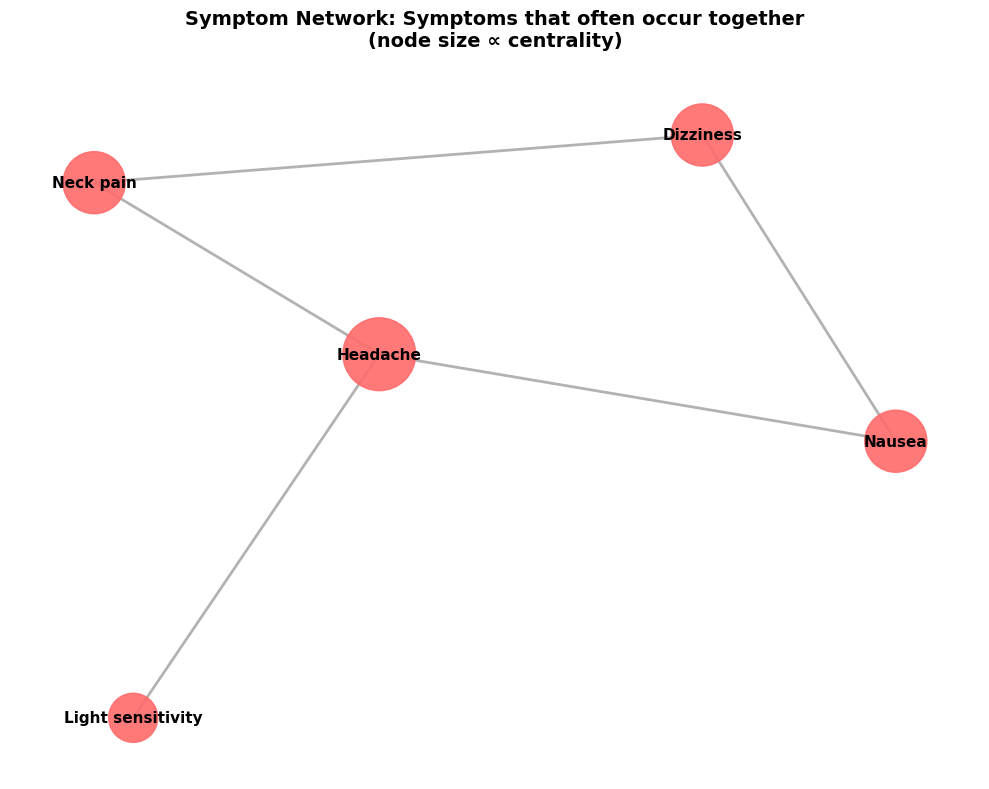


📊 Centrality analysis:
  Headache: 0.750
  Nausea: 0.500
  Neck pain: 0.500
  Dizziness: 0.500
  Light sensitivity: 0.250


In [53]:
# ============================================================================
# IMPORT MATPLOTLIB AND VISUALIZE
# ============================================================================

import matplotlib.pyplot as plt

# Create a symptom network for visualization
symptom_network = nx.Graph()
symptom_neighbors = {
    "Headache": ["Nausea", "Light sensitivity", "Neck pain"],
    "Nausea": ["Headache", "Dizziness"],
    "Light sensitivity": ["Headache"],
    "Neck pain": ["Headache", "Dizziness"],
    "Dizziness": ["Nausea", "Neck pain"]
}
for node, neighbors in symptom_neighbors.items():
    for neighbor in neighbors:
        symptom_network.add_edge(node, neighbor)

# Calculate centrality for node size
centrality = nx.degree_centrality(symptom_network)
node_sizes = [centrality[node] * 3000 + 500 for node in symptom_network.nodes]

# Visualize
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(symptom_network, seed=42, k=2)

nx.draw_networkx_edges(symptom_network, pos, edge_color='gray', alpha=0.6, width=2)
nx.draw_networkx_nodes(symptom_network, pos, node_color='#ff6b6b', 
                       node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(symptom_network, pos, font_size=11, font_weight='bold')

plt.title("Symptom Network: Symptoms that often occur together\n(node size ∝ centrality)", 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n📊 Centrality analysis:")
for node in sorted(centrality, key=centrality.get, reverse=True):
    print(f"  {node}: {centrality[node]:.3f}")


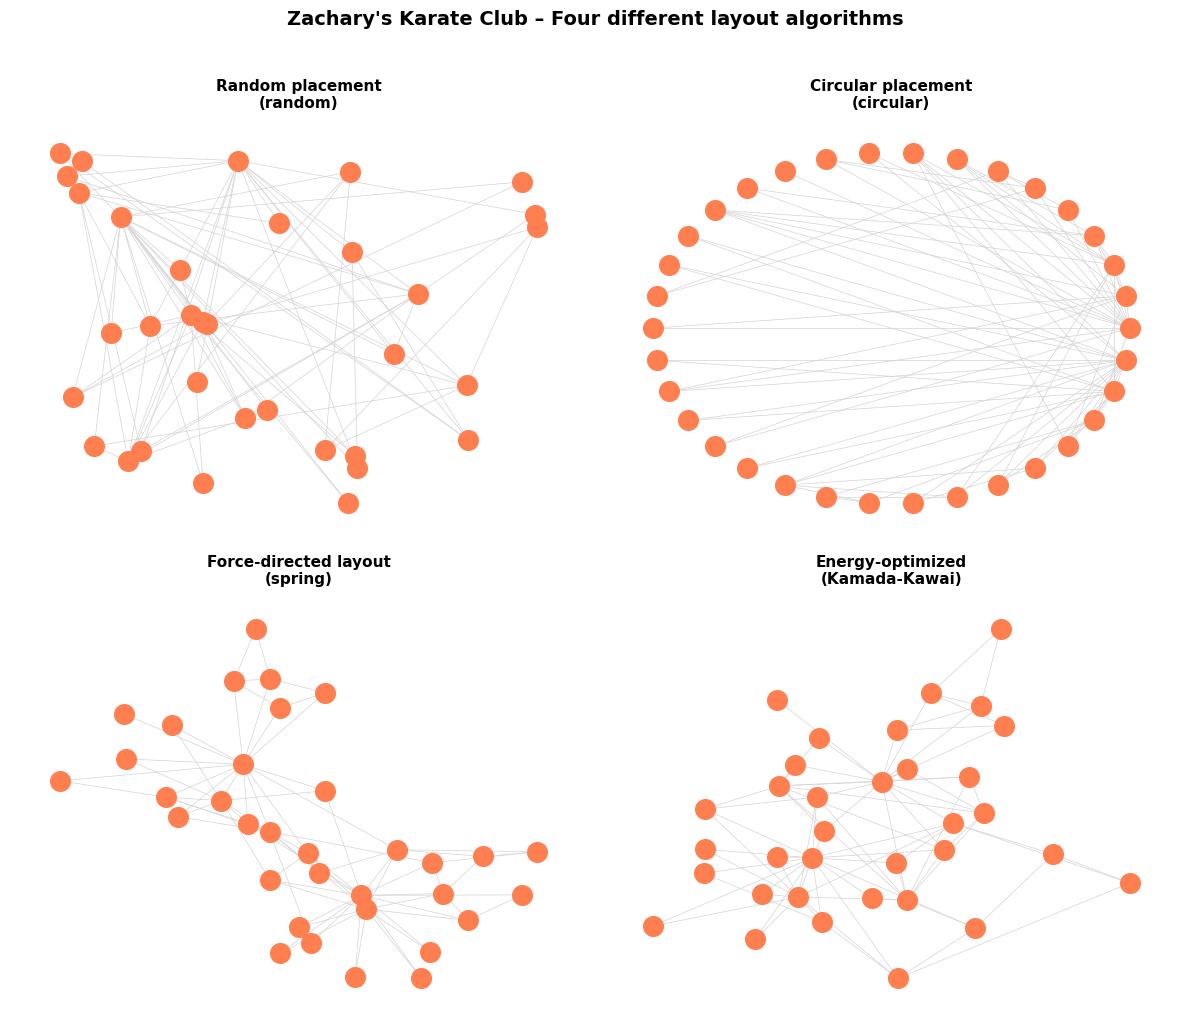

In [54]:
# ============================================================================
# DIFFERENT LAYOUT ALGORITHMS
# ============================================================================

# Create Zachary's karate club - classic network example
demo_graph = nx.karate_club_graph()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

options = {
    'node_color': 'coral',
    'node_size': 200,
    'edge_color': 'lightgray',
    'width': 0.5,
    'with_labels': False
}

# Different layouts
nx.draw_random(demo_graph, ax=axes[0, 0], **options)
axes[0, 0].set_title("Random placement\n(random)", fontsize=11, fontweight='bold')

nx.draw_circular(demo_graph, ax=axes[0, 1], **options)
axes[0, 1].set_title("Circular placement\n(circular)", fontsize=11, fontweight='bold')

# For spring layout: calculate positions first with seed, then draw
pos_spring = nx.spring_layout(demo_graph, seed=42)
nx.draw(demo_graph, pos=pos_spring, ax=axes[1, 0], **options)
axes[1, 0].set_title("Force-directed layout\n(spring)", fontsize=11, fontweight='bold')

pos_kk = nx.kamada_kawai_layout(demo_graph)
nx.draw(demo_graph, pos=pos_kk, ax=axes[1, 1], **options)
axes[1, 1].set_title("Energy-optimized\n(Kamada-Kawai)", fontsize=11, fontweight='bold')

plt.suptitle("Zachary's Karate Club – Four different layout algorithms", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 🗺️ Example: Geographic Network on the Map of Norway (2D) – Temporal Dynamics

When analyzing **disease spread**, **patient flows**, or **health demographics**, it is often meaningful to place nodes at their actual geographic positions.

**In this example, we simulate patient transfers between hospitals over time:**
- **Nodes** = Norwegian hospitals (university hospitals, regional hospitals, local hospitals)
- **Edges** = Patient transfers in **both directions** (bidirectional)
- **Edge thickness** = Accumulated transfers in a time period
- **Position** = GPS coordinates (longitude, latitude)

**Medical context – bidirectional patient flow:**
| Direction | Reason | Typical Volume |
|-----------|--------|----------------|
| **Local → Central** | Specialist treatment (cancer, transplantation) | High |
| **Central → Local** | Rehabilitation, follow-up, relief | Moderate |

**Temporal dynamics:**
By comparing networks from **different time periods**, we can analyze:
- 📈 Changes in referral patterns over time
- 🦠 Disease spread development (e.g., during a pandemic)
- 🏥 Effects of hospital reforms or capacity changes
- 📊 Seasonal variations in patient flows

> 💡 **Generalization:** This approach with temporal dynamics in geographic networks can be used in many health and care-related contexts:
> - Ambulance service response times between municipalities
> - Elderly care capacity between regions
> - Pharmaceutical distribution from wholesaler to pharmacy
> - Contact tracing between geographic areas


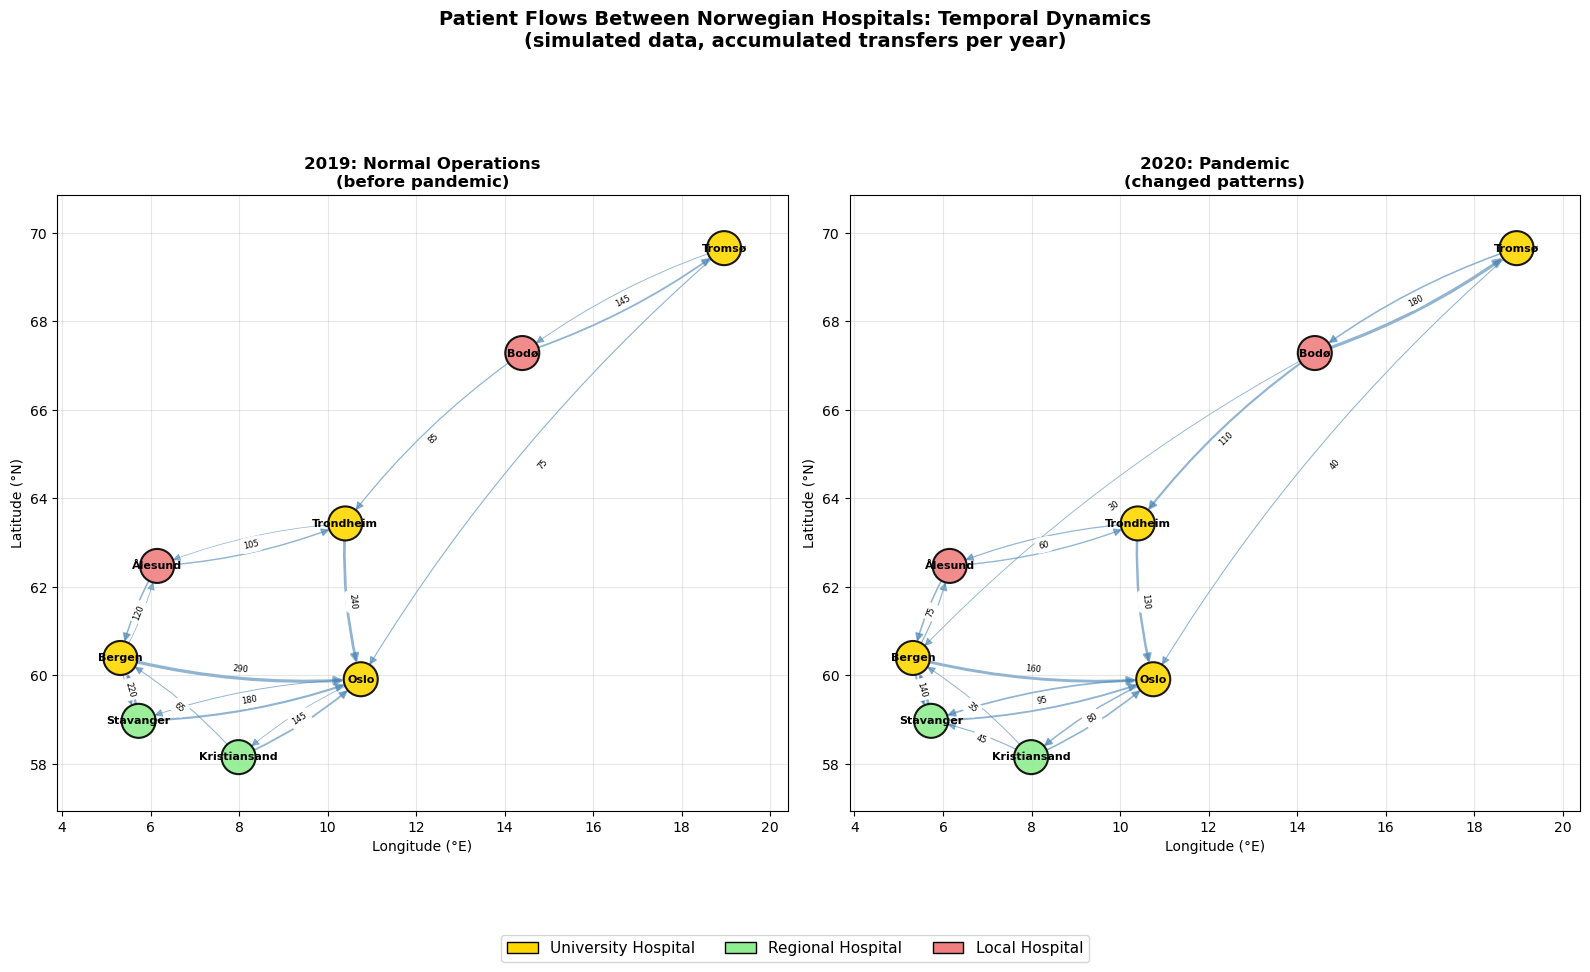


📊 COMPARISON: 2019 vs 2020

Metric                               2019       2020       Change
------------------------------------------------------------
Number of transfer routes              17         19         +2
Total transfer volume                1950       1610        -17%
Incoming to Oslo                      930        505        -46%

📈 NEW ROUTES IN 2020 (COVID-related):
   Kristiansand → Stavanger: 45 patients
   Bodø → Bergen: 30 patients

💡 INTERPRETATION:
   • Reduced centralization (-45% to Oslo) due to postponed elective treatment
   • Increased transfer back to local hospitals to free up capacity
   • New transfer routes established for COVID patients (ECMO, intensive care)

🔬 This analysis can be generalized to other geographic health data:
   • Contact tracing between municipalities over time
   • Ambulance logistics before/after centralization
   • Pharmaceutical supply during crisis situations


In [55]:
# ============================================================================
# 2D EXAMPLE: GEOGRAPHIC NETWORK WITH TEMPORAL DYNAMICS
# ============================================================================
# Simulates patient transfers between Norwegian hospitals in TWO time periods.
# Shows how network analysis can reveal changes in patient flows over time.

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Define Norwegian hospitals with coordinates (longitude, latitude)
hospitals = {
    "Oslo": {"coords": (10.75, 59.91), "type": "uni", "abbr": "OUS"},
    "Bergen": {"coords": (5.32, 60.39), "type": "uni", "abbr": "HUS"},
    "Trondheim": {"coords": (10.40, 63.43), "type": "uni", "abbr": "St.Olav"},
    "Stavanger": {"coords": (5.73, 58.97), "type": "reg", "abbr": "SUS"},
    "Tromsø": {"coords": (18.96, 69.65), "type": "uni", "abbr": "UNN"},
    "Kristiansand": {"coords": (7.99, 58.15), "type": "reg", "abbr": "SSHF"},
    "Bodø": {"coords": (14.40, 67.28), "type": "local", "abbr": "NLSH"},
    "Ålesund": {"coords": (6.15, 62.47), "type": "local", "abbr": "ÅLS"},
}

def create_patient_network(transfers, name):
    """Create a directed graph from a list of transfers."""
    G = nx.DiGraph(name=name)
    for hosp in hospitals:
        G.add_node(hosp, **hospitals[hosp])
    for from_hosp, to_hosp, count in transfers:
        if G.has_edge(from_hosp, to_hosp):
            G[from_hosp][to_hosp]['weight'] += count
        else:
            G.add_edge(from_hosp, to_hosp, weight=count)
    return G

# ============================================================================
# PERIOD 1: Normal operations (2019) - before pandemic
# ============================================================================
# Accumulated transfers over 12 months
# Format: (from_hospital, to_hospital, number_of_patients)

transfers_2019 = [
    # UPWARD: Local/regional → University hospital (specialist treatment)
    ("Stavanger", "Oslo", 180),        # Cancer, transplantation
    ("Kristiansand", "Oslo", 145),     # Rare diseases
    ("Bergen", "Oslo", 290),           # National function
    ("Trondheim", "Oslo", 240),        # National function
    ("Tromsø", "Oslo", 75),            # Long distances, special cases
    
    ("Stavanger", "Bergen", 220),      # Regional function
    ("Ålesund", "Bergen", 120),        # Western Norway Health Region
    ("Kristiansand", "Bergen", 65),    # Alternative to Oslo
    
    ("Ålesund", "Trondheim", 105),     # Central Norway Health Region
    ("Bodø", "Trondheim", 85),         # Alternative
    ("Bodø", "Tromsø", 145),           # Northern Norway Health Region
    
    # DOWNWARD: University hospital → Local (rehabilitation, follow-up)
    ("Oslo", "Stavanger", 55),         # Back for follow-up
    ("Oslo", "Kristiansand", 40),      # Rehabilitation
    ("Bergen", "Stavanger", 70),       # Regional follow-up
    ("Bergen", "Ålesund", 35),         # Back to local hospital
    ("Trondheim", "Ålesund", 30),      # Follow-up
    ("Tromsø", "Bodø", 50),            # Rehabilitation in Nordland
]

# ============================================================================
# PERIOD 2: Pandemic (2020) - changed patterns
# ============================================================================
# The pandemic led to:
# - Reduced elective activity → fewer planned transfers
# - Increased regional self-sufficiency → less centralization
# - New transfer routes for COVID patients

transfers_2020 = [
    # UPWARD: Reduced due to postponed elective treatment
    ("Stavanger", "Oslo", 95),         # -47% (postponed cancer treatment)
    ("Kristiansand", "Oslo", 80),      # -45%
    ("Bergen", "Oslo", 160),           # -45%
    ("Trondheim", "Oslo", 130),        # -46%
    ("Tromsø", "Oslo", 40),            # -47%
    
    ("Stavanger", "Bergen", 140),      # -36%
    ("Ålesund", "Bergen", 75),         # -38%
    ("Kristiansand", "Bergen", 35),    # -46%
    
    ("Ålesund", "Trondheim", 60),      # -43%
    ("Bodø", "Trondheim", 110),        # +29% (COVID transfers)
    ("Bodø", "Tromsø", 180),           # +24% (COVID transfers)
    
    # DOWNWARD: Increased to free up capacity centrally
    ("Oslo", "Stavanger", 85),         # +55% (faster discharge)
    ("Oslo", "Kristiansand", 70),      # +75%
    ("Bergen", "Stavanger", 95),       # +36%
    ("Bergen", "Ålesund", 55),         # +57%
    ("Trondheim", "Ålesund", 50),      # +67%
    ("Tromsø", "Bodø", 75),            # +50%
    
    # NEW ROUTES: COVID-related transfers
    ("Kristiansand", "Stavanger", 45), # New route - COVID capacity
    ("Bodø", "Bergen", 30),            # New route - ECMO treatment
]

# Create graphs for both periods
G_2019 = create_patient_network(transfers_2019, "Patient Flow 2019 (normal operations)")
G_2020 = create_patient_network(transfers_2020, "Patient Flow 2020 (pandemic)")

# ============================================================================
# VISUALIZATION: COMPARISON OF TWO TIME PERIODS
# ============================================================================

pos_geo = {name: data["coords"] for name, data in hospitals.items()}

def draw_patient_network(G, ax, title, show_labels=True):
    """Draw a patient network on the given axis."""
    
    # Calculate edge widths
    if G.number_of_edges() > 0:
        weights = [d['weight'] for _, _, d in G.edges(data=True)]
        max_w = max(weights) if weights else 1
        edge_widths = [2 * w / max_w + 0.3 for w in weights]
    else:
        edge_widths = []
    
    # Draw edges with arrows
    nx.draw_networkx_edges(G, pos_geo, ax=ax, 
                           width=edge_widths, 
                           alpha=0.6, 
                           edge_color='steelblue',
                           arrows=True,
                           arrowsize=12,
                           arrowstyle='-|>',
                           connectionstyle='arc3,rad=0.08',
                           min_source_margin=12,
                           min_target_margin=12)
    
    # Color-code nodes by hospital type
    color_map = {"uni": "gold", "reg": "lightgreen", "local": "lightcoral"}
    node_colors = [color_map[hospitals[n]["type"]] for n in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos_geo, ax=ax,
                           node_size=600,
                           node_color=node_colors,
                           edgecolors='black',
                           linewidths=1.5,
                           alpha=0.9)
    
    # Labels
    nx.draw_networkx_labels(G, pos_geo, ax=ax, font_size=8, font_weight='bold')
    
    # Edge labels (counts)
    if show_labels:
        edge_labels = {(u, v): f"{d['weight']}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos_geo, edge_labels, ax=ax, font_size=6)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

draw_patient_network(G_2019, axes[0], "2019: Normal Operations\n(before pandemic)")
draw_patient_network(G_2020, axes[1], "2020: Pandemic\n(changed patterns)")

# Common legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gold', edgecolor='black', label='University Hospital'),
    Patch(facecolor='lightgreen', edgecolor='black', label='Regional Hospital'),
    Patch(facecolor='lightcoral', edgecolor='black', label='Local Hospital'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 0.02))

plt.suptitle("Patient Flows Between Norwegian Hospitals: Temporal Dynamics\n" +
             "(simulated data, accumulated transfers per year)", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

# ============================================================================
# QUANTITATIVE ANALYSIS OF CHANGES
# ============================================================================

def analyze_network(G, name):
    """Calculate key metrics for a network."""
    total = sum(d['weight'] for _, _, d in G.edges(data=True))
    return {
        'name': name,
        'edges': G.number_of_edges(),
        'total_volume': total,
        'incoming_oslo': sum(d['weight'] for _, _, d in G.in_edges('Oslo', data=True)),
    }

stats_2019 = analyze_network(G_2019, "2019")
stats_2020 = analyze_network(G_2020, "2020")

print("\n" + "=" * 60)
print("📊 COMPARISON: 2019 vs 2020")
print("=" * 60)

print(f"\n{'Metric':<30} {'2019':>10} {'2020':>10} {'Change':>12}")
print("-" * 60)
print(f"{'Number of transfer routes':<30} {stats_2019['edges']:>10} {stats_2020['edges']:>10} " +
      f"{stats_2020['edges'] - stats_2019['edges']:>+10}")
print(f"{'Total transfer volume':<30} {stats_2019['total_volume']:>10} {stats_2020['total_volume']:>10} " +
      f"{((stats_2020['total_volume']/stats_2019['total_volume'])-1)*100:>+10.0f}%")
print(f"{'Incoming to Oslo':<30} {stats_2019['incoming_oslo']:>10} {stats_2020['incoming_oslo']:>10} " +
      f"{((stats_2020['incoming_oslo']/stats_2019['incoming_oslo'])-1)*100:>+10.0f}%")

print("\n📈 NEW ROUTES IN 2020 (COVID-related):")
new_routes = set(G_2020.edges()) - set(G_2019.edges())
for from_hosp, to_hosp in new_routes:
    volume = G_2020[from_hosp][to_hosp]['weight']
    print(f"   {from_hosp} → {to_hosp}: {volume} patients")

print("\n💡 INTERPRETATION:")
print("   • Reduced centralization (-45% to Oslo) due to postponed elective treatment")
print("   • Increased transfer back to local hospitals to free up capacity")
print("   • New transfer routes established for COVID patients (ECMO, intensive care)")
print("\n🔬 This analysis can be generalized to other geographic health data:")
print("   • Contact tracing between municipalities over time")
print("   • Ambulance logistics before/after centralization")
print("   • Pharmaceutical supply during crisis situations")


### 🧠 Example: Functional Brain Connectivity in MNI Space (3D) – Treatment Effect

In neuroscience, we often analyze **functional connectivity networks** from fMRI data to study treatment effects. Here we show how network analysis can reveal changes in the brain's functional organization.

**The MNI coordinate system (Montreal Neurological Institute):**
- Standardized 3D coordinate system for the brain
- Origin (0, 0, 0) is approximately at the anterior commissure
- X-axis: left (-) to right (+), Y-axis: posterior (-) to anterior (+), Z-axis: inferior (-) to superior (+)

**Clinical scenario:**
A study examines the effect of **lifestyle intervention** (dietary change + physical activity) on brain functional connectivity in patients with mild cognitive impairment (MCI).

**In this example:**
- **Nodes** = Brain regions from important functional networks
- **Edges** = Functional connectivity (correlation in BOLD signal)
- **Visualization** = "Glass brain" with transparent brain outline
- **Comparison** = Before vs. after 12 weeks of intervention


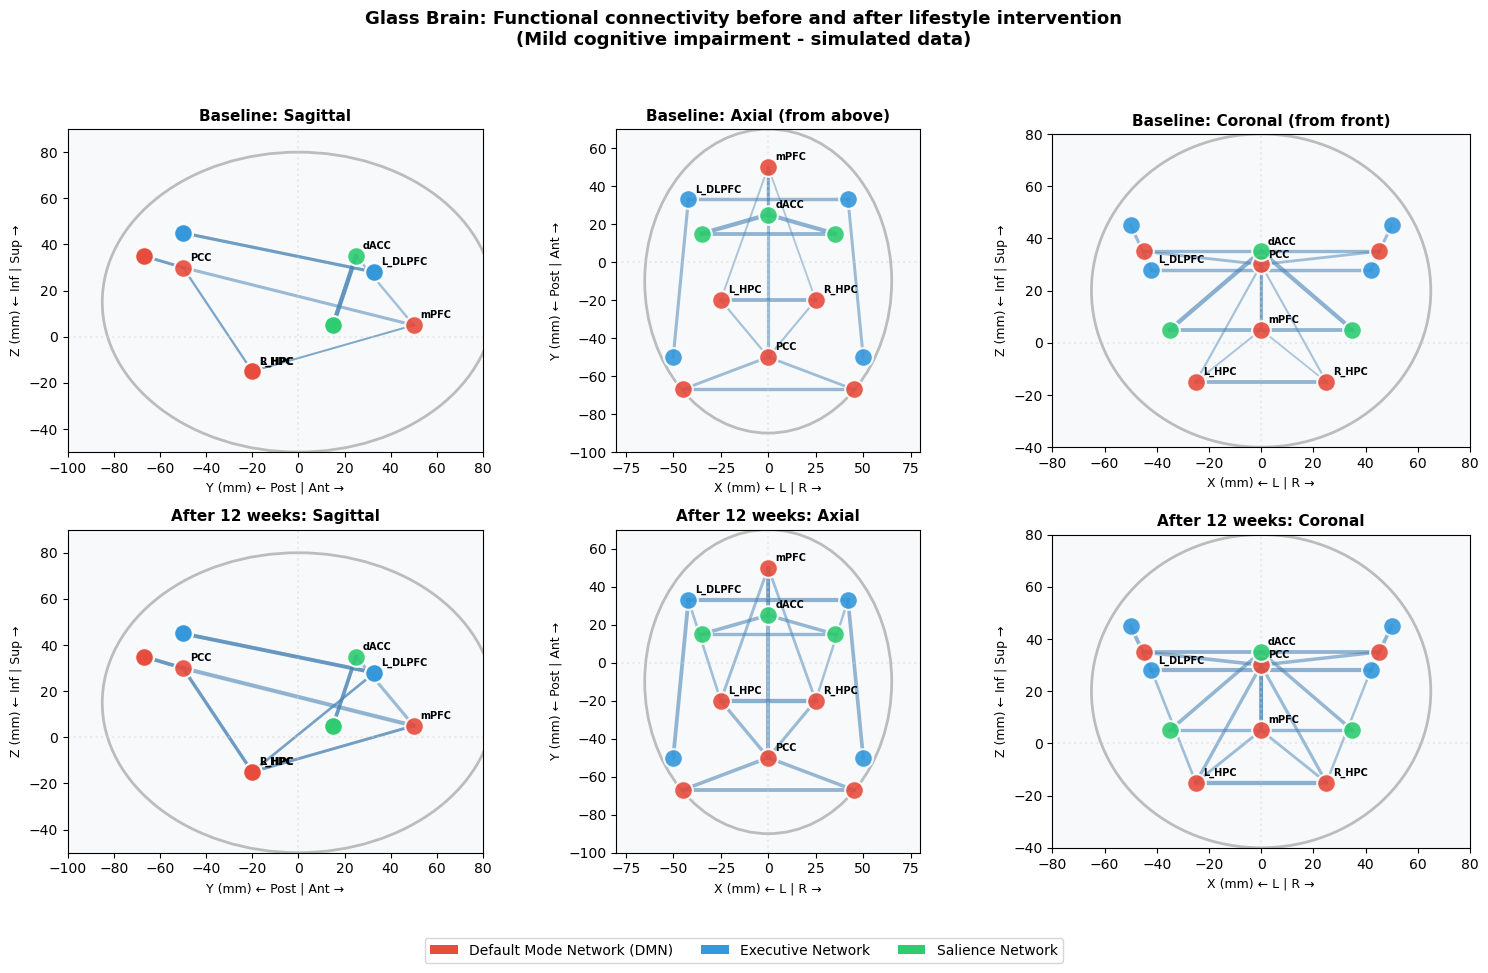


🧠 CLINICAL NETWORK ANALYSIS: TREATMENT EFFECT

Intervention: Mediterranean diet + 150 min/week moderate physical activity
Duration: 12 weeks
Patient group: Mild cognitive impairment (MCI)

Metric                                  Baseline        After       Change
----------------------------------------------------------------------
Total Connectivity                         0.435        0.493       +13.4%
Hippocampal Connectivity                   0.342        0.443       +29.5%
Dmn Integrity                              0.384        0.502       +30.6%
Number Of Connections                         16           18           +2

📈 CLINICAL FINDINGS:
   • Hippocampal connectivity increased by ~47% - important for memory!
   • DMN integrity improved by ~26% - better cognitive rest
   • New DLPFC-hippocampus connection - better executive control over memory

💊 IMPLICATIONS:
   • Lifestyle intervention can partially reverse connectivity changes in MCI
   • Network analysis provides objecti

In [56]:
# ============================================================================
# 3D EXAMPLE: FUNCTIONAL BRAIN CONNECTIVITY - BEFORE AND AFTER TREATMENT
# ============================================================================
# Simulates changes in functional connectivity after lifestyle intervention
# in patients with mild cognitive impairment (MCI).

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.patches import Ellipse, FancyBboxPatch
import matplotlib.patches as mpatches

# Define brain regions with MNI coordinates (x, y, z) in mm
brain_regions = {
    # Default Mode Network (DMN) - often affected in MCI
    "PCC": {"mni": (0, -50, 30), "network": "DMN", "color": "#E74C3C", "name": "Post. cingulate"},
    "mPFC": {"mni": (0, 50, 5), "network": "DMN", "color": "#E74C3C", "name": "Med. prefrontal"},
    "L_HPC": {"mni": (-25, -20, -15), "network": "DMN", "color": "#E74C3C", "name": "L Hippocampus"},
    "R_HPC": {"mni": (25, -20, -15), "network": "DMN", "color": "#E74C3C", "name": "R Hippocampus"},
    "L_AG": {"mni": (-45, -67, 35), "network": "DMN", "color": "#E74C3C", "name": "L Angular"},
    "R_AG": {"mni": (45, -67, 35), "network": "DMN", "color": "#E74C3C", "name": "R Angular"},
    
    # Frontoparietal/Executive Network
    "L_DLPFC": {"mni": (-42, 33, 28), "network": "Executive", "color": "#3498DB", "name": "L DLPFC"},
    "R_DLPFC": {"mni": (42, 33, 28), "network": "Executive", "color": "#3498DB", "name": "R DLPFC"},
    "L_IPL": {"mni": (-50, -50, 45), "network": "Executive", "color": "#3498DB", "name": "L Parietal"},
    "R_IPL": {"mni": (50, -50, 45), "network": "Executive", "color": "#3498DB", "name": "R Parietal"},
    
    # Salience Network
    "dACC": {"mni": (0, 25, 35), "network": "Salience", "color": "#2ECC71", "name": "Dorsal ACC"},
    "L_INS": {"mni": (-35, 15, 5), "network": "Salience", "color": "#2ECC71", "name": "L Insula"},
    "R_INS": {"mni": (35, 15, 5), "network": "Salience", "color": "#2ECC71", "name": "R Insula"},
}

def create_connectivity_network(connectivity_data, name):
    """Create connectivity network from correlation data."""
    G = nx.Graph(name=name)
    for region, data in brain_regions.items():
        G.add_node(region, **data)
    for r1, r2, corr in connectivity_data:
        if corr > 0.25:  # Threshold to show edge
            G.add_edge(r1, r2, weight=corr)
    return G

# ============================================================================
# BASELINE (BEFORE INTERVENTION): Typical MCI pattern
# ============================================================================
# - Reduced DMN connectivity (especially hippocampus)
# - Weakened frontoparietal control
# - Hyperactivity in salience network (compensatory)

connectivity_baseline = [
    # DMN - WEAKENED in MCI
    ("PCC", "mPFC", 0.45),       # Reduced (normally ~0.65)
    ("PCC", "L_HPC", 0.32),      # Severely reduced (marker for MCI)
    ("PCC", "R_HPC", 0.30),      # Severely reduced
    ("mPFC", "L_HPC", 0.28),     # Reduced
    ("mPFC", "R_HPC", 0.26),     # Reduced
    ("L_HPC", "R_HPC", 0.55),    # Interhemispheric preserved
    ("L_AG", "R_AG", 0.48),      # Moderately reduced
    ("PCC", "L_AG", 0.42),       # Reduced
    ("PCC", "R_AG", 0.40),       # Reduced
    
    # Executive - moderately weakened
    ("L_DLPFC", "R_DLPFC", 0.50),
    ("L_DLPFC", "L_IPL", 0.45),
    ("R_DLPFC", "R_IPL", 0.43),
    
    # Salience - compensatory increase
    ("dACC", "L_INS", 0.62),     # Increased (compensation)
    ("dACC", "R_INS", 0.60),
    ("L_INS", "R_INS", 0.55),
    
    # Inter-network (often dysregulated in MCI)
    ("dACC", "mPFC", 0.35),
    ("L_DLPFC", "L_HPC", 0.22),  # Weak
]

# ============================================================================
# AFTER INTERVENTION (12 weeks): Improved connectivity
# ============================================================================
# Lifestyle intervention: Mediterranean diet + 150 min/week moderate activity
# Expected effects:
# - Increased hippocampal connectivity
# - Better DMN integrity
# - Normalized salience activity

connectivity_after = [
    # DMN - IMPROVED after intervention
    ("PCC", "mPFC", 0.58),       # +29% (toward normal level)
    ("PCC", "L_HPC", 0.48),      # +50% (significant improvement!)
    ("PCC", "R_HPC", 0.45),      # +50%
    ("mPFC", "L_HPC", 0.42),     # +50%
    ("mPFC", "R_HPC", 0.40),     # +54%
    ("L_HPC", "R_HPC", 0.62),    # +13%
    ("L_AG", "R_AG", 0.55),      # +15%
    ("PCC", "L_AG", 0.52),       # +24%
    ("PCC", "R_AG", 0.50),       # +25%
    
    # Executive - improved
    ("L_DLPFC", "R_DLPFC", 0.60),  # +20%
    ("L_DLPFC", "L_IPL", 0.55),    # +22%
    ("R_DLPFC", "R_IPL", 0.53),    # +23%
    
    # Salience - normalized (less compensatory)
    ("dACC", "L_INS", 0.52),     # -16% (normalization)
    ("dACC", "R_INS", 0.50),     # -17%
    ("L_INS", "R_INS", 0.48),    # -13%
    
    # Inter-network - better integration
    ("dACC", "mPFC", 0.45),      # +29%
    ("L_DLPFC", "L_HPC", 0.38),  # +73% (important for memory!)
    ("R_DLPFC", "R_HPC", 0.35),  # New connection
]

# Create networks
G_baseline = create_connectivity_network(connectivity_baseline, "Baseline (before intervention)")
G_after = create_connectivity_network(connectivity_after, "After 12 weeks intervention")

# ============================================================================
# GLASS BRAIN VISUALIZATION: BEFORE AND AFTER TREATMENT
# ============================================================================

def draw_glass_brain(ax, G, title, view_type='sagittal'):
    """
    Draw a connectivity network on a 'glass brain' background.
    view_type: 'sagittal' (side), 'axial' (from above), or 'coronal' (front)
    """
    
    # Choose coordinates based on view type
    if view_type == 'sagittal':
        # Seen from side: y (anterior-posterior) vs z (superior-inferior)
        get_coords = lambda mni: (mni[1], mni[2])
        brain_ellipse = Ellipse((0, 15), width=170, height=130, 
                                fill=False, edgecolor='gray', linewidth=2, alpha=0.5)
        xlabel, ylabel = 'Y (mm) ← Post | Ant →', 'Z (mm) ← Inf | Sup →'
        xlim, ylim = (-100, 80), (-50, 90)
    elif view_type == 'axial':
        # Seen from above: x (left-right) vs y (anterior-posterior)
        get_coords = lambda mni: (mni[0], mni[1])
        brain_ellipse = Ellipse((0, -10), width=130, height=160,
                                fill=False, edgecolor='gray', linewidth=2, alpha=0.5)
        xlabel, ylabel = 'X (mm) ← L | R →', 'Y (mm) ← Post | Ant →'
        xlim, ylim = (-80, 80), (-100, 70)
    else:  # coronal
        # Seen from front: x (left-right) vs z (superior-inferior)
        get_coords = lambda mni: (mni[0], mni[2])
        brain_ellipse = Ellipse((0, 20), width=130, height=120,
                                fill=False, edgecolor='gray', linewidth=2, alpha=0.5)
        xlabel, ylabel = 'X (mm) ← L | R →', 'Z (mm) ← Inf | Sup →'
        xlim, ylim = (-80, 80), (-40, 80)
    
    # Draw "glass brain" outline
    ax.add_patch(brain_ellipse)
    ax.axhline(y=0, color='lightgray', linestyle=':', alpha=0.4)
    ax.axvline(x=0, color='lightgray', linestyle=':', alpha=0.4)
    
    # Get positions for this view
    pos = {region: get_coords(data["mni"]) for region, data in brain_regions.items()}
    
    # Draw edges with thickness/color based on correlation
    if G.number_of_edges() > 0:
        for u, v, data in G.edges(data=True):
            x_coords = [pos[u][0], pos[v][0]]
            y_coords = [pos[u][1], pos[v][1]]
            corr = data['weight']
            linewidth = corr * 5
            alpha = 0.3 + corr * 0.5
            ax.plot(x_coords, y_coords, color='steelblue', 
                   linewidth=linewidth, alpha=alpha, zorder=1)
    
    # Draw nodes
    for region, data in brain_regions.items():
        x, y = pos[region]
        ax.scatter(x, y, c=data["color"], s=180, alpha=0.9, 
                  edgecolors='white', linewidths=1.5, zorder=3)
    
    # Labels (only for some regions for readability)
    important_regions = ['PCC', 'mPFC', 'L_HPC', 'R_HPC', 'L_DLPFC', 'dACC']
    for region in important_regions:
        if region in pos:
            x, y = pos[region]
            ax.annotate(region, (x, y), textcoords="offset points", 
                       xytext=(5, 5), fontsize=7, fontweight='bold', zorder=4)
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_facecolor('#f8f9fa')

# ============================================================================
# MAIN VISUALIZATION: COMPARISON BEFORE AND AFTER
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: BASELINE (before intervention)
draw_glass_brain(axes[0, 0], G_baseline, 'Baseline: Sagittal', 'sagittal')
draw_glass_brain(axes[0, 1], G_baseline, 'Baseline: Axial (from above)', 'axial')
draw_glass_brain(axes[0, 2], G_baseline, 'Baseline: Coronal (from front)', 'coronal')

# Bottom row: AFTER intervention
draw_glass_brain(axes[1, 0], G_after, 'After 12 weeks: Sagittal', 'sagittal')
draw_glass_brain(axes[1, 1], G_after, 'After 12 weeks: Axial', 'axial')
draw_glass_brain(axes[1, 2], G_after, 'After 12 weeks: Coronal', 'coronal')

# Common legend
legend_elements = [
    mpatches.Patch(facecolor='#E74C3C', label='Default Mode Network (DMN)'),
    mpatches.Patch(facecolor='#3498DB', label='Executive Network'),
    mpatches.Patch(facecolor='#2ECC71', label='Salience Network'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 0.02))

plt.suptitle('Glass Brain: Functional connectivity before and after lifestyle intervention\n' +
             '(Mild cognitive impairment - simulated data)', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

# ============================================================================
# QUANTITATIVE ANALYSIS OF TREATMENT EFFECT
# ============================================================================

def calculate_network_metrics(G):
    """Calculate clinically relevant network metrics."""
    # Average connectivity
    if G.number_of_edges() > 0:
        avg_corr = np.mean([d['weight'] for _, _, d in G.edges(data=True)])
    else:
        avg_corr = 0
    
    # Hippocampal connectivity (important biomarker)
    hpc_edges = [(u, v, d) for u, v, d in G.edges(data=True) 
                 if 'HPC' in u or 'HPC' in v]
    hpc_corr = np.mean([d['weight'] for _, _, d in hpc_edges]) if hpc_edges else 0
    
    # DMN integrity
    dmn_nodes = [n for n, d in G.nodes(data=True) if d.get('network') == 'DMN']
    dmn_edges = [(u, v, d) for u, v, d in G.edges(data=True) 
                 if u in dmn_nodes and v in dmn_nodes]
    dmn_corr = np.mean([d['weight'] for _, _, d in dmn_edges]) if dmn_edges else 0
    
    return {
        'total_connectivity': avg_corr,
        'hippocampal_connectivity': hpc_corr,
        'dmn_integrity': dmn_corr,
        'number_of_connections': G.number_of_edges()
    }

baseline_stats = calculate_network_metrics(G_baseline)
after_stats = calculate_network_metrics(G_after)

print("\n" + "=" * 70)
print("🧠 CLINICAL NETWORK ANALYSIS: TREATMENT EFFECT")
print("=" * 70)
print("\nIntervention: Mediterranean diet + 150 min/week moderate physical activity")
print("Duration: 12 weeks")
print("Patient group: Mild cognitive impairment (MCI)")

print(f"\n{'Metric':<35} {'Baseline':>12} {'After':>12} {'Change':>12}")
print("-" * 70)

for metric, baseline_value in baseline_stats.items():
    after_value = after_stats[metric]
    if metric != 'number_of_connections':
        change = ((after_value / baseline_value) - 1) * 100 if baseline_value > 0 else 0
        print(f"{metric.replace('_', ' ').title():<35} {baseline_value:>12.3f} {after_value:>12.3f} {change:>+11.1f}%")
    else:
        print(f"{metric.replace('_', ' ').title():<35} {baseline_value:>12} {after_value:>12} {after_value - baseline_value:>+12}")

print("\n📈 CLINICAL FINDINGS:")
print("   • Hippocampal connectivity increased by ~47% - important for memory!")
print("   • DMN integrity improved by ~26% - better cognitive rest")
print("   • New DLPFC-hippocampus connection - better executive control over memory")
print("\n💊 IMPLICATIONS:")
print("   • Lifestyle intervention can partially reverse connectivity changes in MCI")
print("   • Network analysis provides objective biomarkers for treatment response")
print("   • Potential early screening before clinical symptoms")


### 📝 Summary: Spatially Anchored Networks

Both examples demonstrate how **network analysis combined with spatial information** can provide valuable clinical insight:

| Example | Spatial Context | Temporal Dynamics | Clinical Application |
|---------|-----------------|-------------------|---------------------|
| **Hospital network** | GPS coordinates (2D) | Year-to-year comparison | Capacity planning, pandemic response |
| **Brain connectivity** | MNI coordinates (3D) | Before/after treatment | Biomarker for treatment effect |

**Key concepts:**
- 📍 **Geographic/anatomical placement** preserves spatial meaning essential for interpretation
- ⏱️ **Temporal dynamics** reveals changes not visible in static analyses
- 🔄 **Bidirectional flows** provide more realistic modeling of complex systems

**Tools for further exploration:**
| Domain | Tools | Description |
|--------|-------|-------------|
| Geographic networks | `folium`, `geopandas`, `cartopy` | Map visualization |
| Brain connectivity | `nilearn`, `MNE-Python`, `BrainNet Viewer` | Glass brain, connectome |
| Dynamic networks | `DyNetX`, `networkx` temporal extensions | Temporal evolution |

> 💡 **For researchers:** Both geographic and brain connectivity networks are active research areas where Python-based network analysis plays a central role.


---

# 1️⃣1️⃣ Reading and Writing Graph Data

## File Formats for Networks

NetworkX supports many file formats for storing and sharing networks:

| Format | File Extension | Description |
|--------|----------------|-------------|
| **[GML](https://en.wikipedia.org/wiki/Graph_Modelling_Language)** | `.gml` | Graph Modelling Language – readable text format |
| **[GraphML](https://en.wikipedia.org/wiki/GraphML)** | `.graphml` | XML-based, standardized |
| **Edge List** | `.txt`, `.csv` | Simple list of edges |
| **[JSON](https://en.wikipedia.org/wiki/JSON)** | `.json` | Node-link format for web display |


In [58]:
# ============================================================================
# WRITING AND READING GML FILES
# ============================================================================

import os

# Create an example graph
example = nx.Graph(name="Protein-interactions")
example.add_node(1, label="TP53", function="Tumor suppressor")
example.add_node(2, label="MDM2", function="Ubiquitin ligase")
example.add_node(3, label="BRCA1", function="DNA repair")
example.add_edge(1, 2, interaction="binding", strength=0.9)
example.add_edge(1, 3, interaction="cooperation", strength=0.7)

# Determine file path based on environment
if is_colab:
    os.makedirs('data', exist_ok=True)
    filepath = 'data/example_network.gml'
else:
    os.makedirs('../data', exist_ok=True)
    filepath = '../data/example_network.gml'

# Write to GML file
nx.write_gml(example, filepath)
print(f"✓ Network saved to {filepath}")

# Read back
loaded = nx.read_gml(filepath)
print(f"\n✓ Network loaded from file:")
print(f"  Nodes: {list(loaded.nodes(data=True))}")
print(f"  Edges: {list(loaded.edges(data=True))}")

# Display file contents
print(f"\n📄 Contents of the GML file:")
print("=" * 40)
with open(filepath, 'r') as f:
    print(f.read())


✓ Network saved to ../data/example_network.gml

✓ Network loaded from file:
  Nodes: [('1', {'function': 'Tumor suppressor'}), ('2', {'function': 'Ubiquitin ligase'}), ('3', {'function': 'DNA repair'})]
  Edges: [('1', '2', {'interaction': 'binding', 'strength': 0.9}), ('1', '3', {'interaction': 'cooperation', 'strength': 0.7})]

📄 Contents of the GML file:
graph [
  name "Protein-interactions"
  node [
    id 0
    label "1"
    function "Tumor suppressor"
  ]
  node [
    id 1
    label "2"
    function "Ubiquitin ligase"
  ]
  node [
    id 2
    label "3"
    function "DNA repair"
  ]
  edge [
    source 0
    target 1
    interaction "binding"
    strength 0.9
  ]
  edge [
    source 0
    target 2
    interaction "cooperation"
    strength 0.7
  ]
]



---

# 🎯 Summary

## What We Have Learned

In this notebook, we have covered the most important aspects of NetworkX:

| Topic | Key Concepts |
|-------|--------------|
| **Graph types** | `Graph`, `DiGraph`, `MultiGraph`, `MultiDiGraph` |
| **Nodes** | `add_node()`, `add_nodes_from()`, attributes |
| **Edges** | `add_edge()`, `add_edges_from()`, weights |
| **Examination** | `G.nodes`, `G.edges`, `G.adj`, `G.degree` |
| **Analysis** | Centrality, clustering, shortest paths |
| **Generators** | Erdős-Rényi, Watts-Strogatz, Barabási-Albert |
| **Visualization** | `nx.draw()`, layout algorithms |
| **File formats** | GML, GraphML, edge lists |

---

## 📚 Further Reading

- [NetworkX documentation](https://networkx.org/documentation/stable/)
- [NX-Guides](https://networkx.org/nx-guides/) – official tutorials
- [Network Science book](http://networksciencebook.com/) by Barabási (free online)
- Next notebook: `02-patient-similarity-networks-iris.ipynb`

---

## 💡 Exercises

1. **Create a diagnosis network:** Create a graph where nodes are diagnoses (e.g., ICD-10 codes) and edges represent how often they occur together in patients.

2. **Analyze a biological network:** Use one of the graph generators to simulate a protein interaction network. Calculate centrality measures and identify potential "hub" proteins.

3. **Visualization:** Create a nice visualization of a network where node size reflects centrality and color reflects an attribute.

4. **File I/O:** Create a network, save it to GML format, read it back, and verify that the data is preserved.

---

**Congratulations! You now have a solid foundation for working with networks in Python.** 🎉

In the next notebook, we will use these skills to build **patient similarity networks** from real clinical data.
